In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
from sklearn import preprocessing, metrics
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
sales_train_val = pd.read_csv('sales_train_validation.csv')
calendar = pd.read_csv('calendar.csv')
selling_prices = pd.read_csv('sell_prices.csv')
sample_submission = pd.read_csv('sample_submission.csv')


In [30]:
ids = sorted(list(set(sales_train_val['id'])))
d_cols = [c for c in sales_train_val.columns if 'd_' in c]
x_1 = sales_train_val.loc[sales_train_val['id'] == ids[2]].set_index('id')[d_cols].values[0]
x_2 = sales_train_val.loc[sales_train_val['id'] == ids[1]].set_index('id')[d_cols].values[0]
x_3 = sales_train_val.loc[sales_train_val['id'] == ids[17]].set_index('id')[d_cols].values[0]

fig = make_subplots(rows=3, cols=1)

fig.add_trace(go.Scatter(x=np.arange(len(x_1)), y=x_1, showlegend=False,
                    mode='lines', name="First sample",
                         marker=dict(color="mediumseagreen")),
             row=1, col=1)

fig.add_trace(go.Scatter(x=np.arange(len(x_2)), y=x_2, showlegend=False,
                    mode='lines', name="Second sample",
                         marker=dict(color="violet")),
             row=2, col=1)

fig.add_trace(go.Scatter(x=np.arange(len(x_3)), y=x_3, showlegend=False,
                    mode='lines', name="Third sample",
                         marker=dict(color="dodgerblue")),
             row=3, col=1)

fig.update_layout(height=1200, width=800, title_text="Sample sales")
fig.show()

In [31]:
ids = sorted(list(set(sales_train_val['id'])))
d_cols = [c for c in sales_train_val.columns if 'd_' in c]
x_1 = sales_train_val.loc[sales_train_val['id'] == ids[0]].set_index('id')[d_cols].values[0][:90]
x_2 = sales_train_val.loc[sales_train_val['id'] == ids[4]].set_index('id')[d_cols].values[0][1300:1400]
x_3 = sales_train_val.loc[sales_train_val['id'] == ids[65]].set_index('id')[d_cols].values[0][350:450]
fig = make_subplots(rows=3, cols=1)

fig.add_trace(go.Scatter(x=np.arange(len(x_1)), y=x_1, showlegend=False,
                    mode='lines+markers', name="First sample",
                         marker=dict(color="mediumseagreen")),
             row=1, col=1)

fig.add_trace(go.Scatter(x=np.arange(len(x_2)), y=x_2, showlegend=False,
                    mode='lines+markers', name="Second sample",
                         marker=dict(color="violet")),
             row=2, col=1)

fig.add_trace(go.Scatter(x=np.arange(len(x_3)), y=x_3, showlegend=False,
                    mode='lines+markers', name="Third sample",
                         marker=dict(color="dodgerblue")),
             row=3, col=1)

fig.update_layout(height=1200, width=800, title_text="Sample sales snippets")
fig.show()

In [36]:
def maddest(d, axis=None):
    return np.mean(np.absolute(d - np.mean(d, axis)), axis)

def denoise_signal(x, wavelet='db4', level=1):
    coeff = pywt.wavedec(x, wavelet, mode="per")
    sigma = (1/0.6745) * maddest(coeff[-level])

    uthresh = sigma * np.sqrt(2*np.log(len(x)))
    coeff[1:] = (pywt.threshold(i, value=uthresh, mode='hard') for i in coeff[1:])

    return pywt.waverec(coeff, wavelet, mode='per')

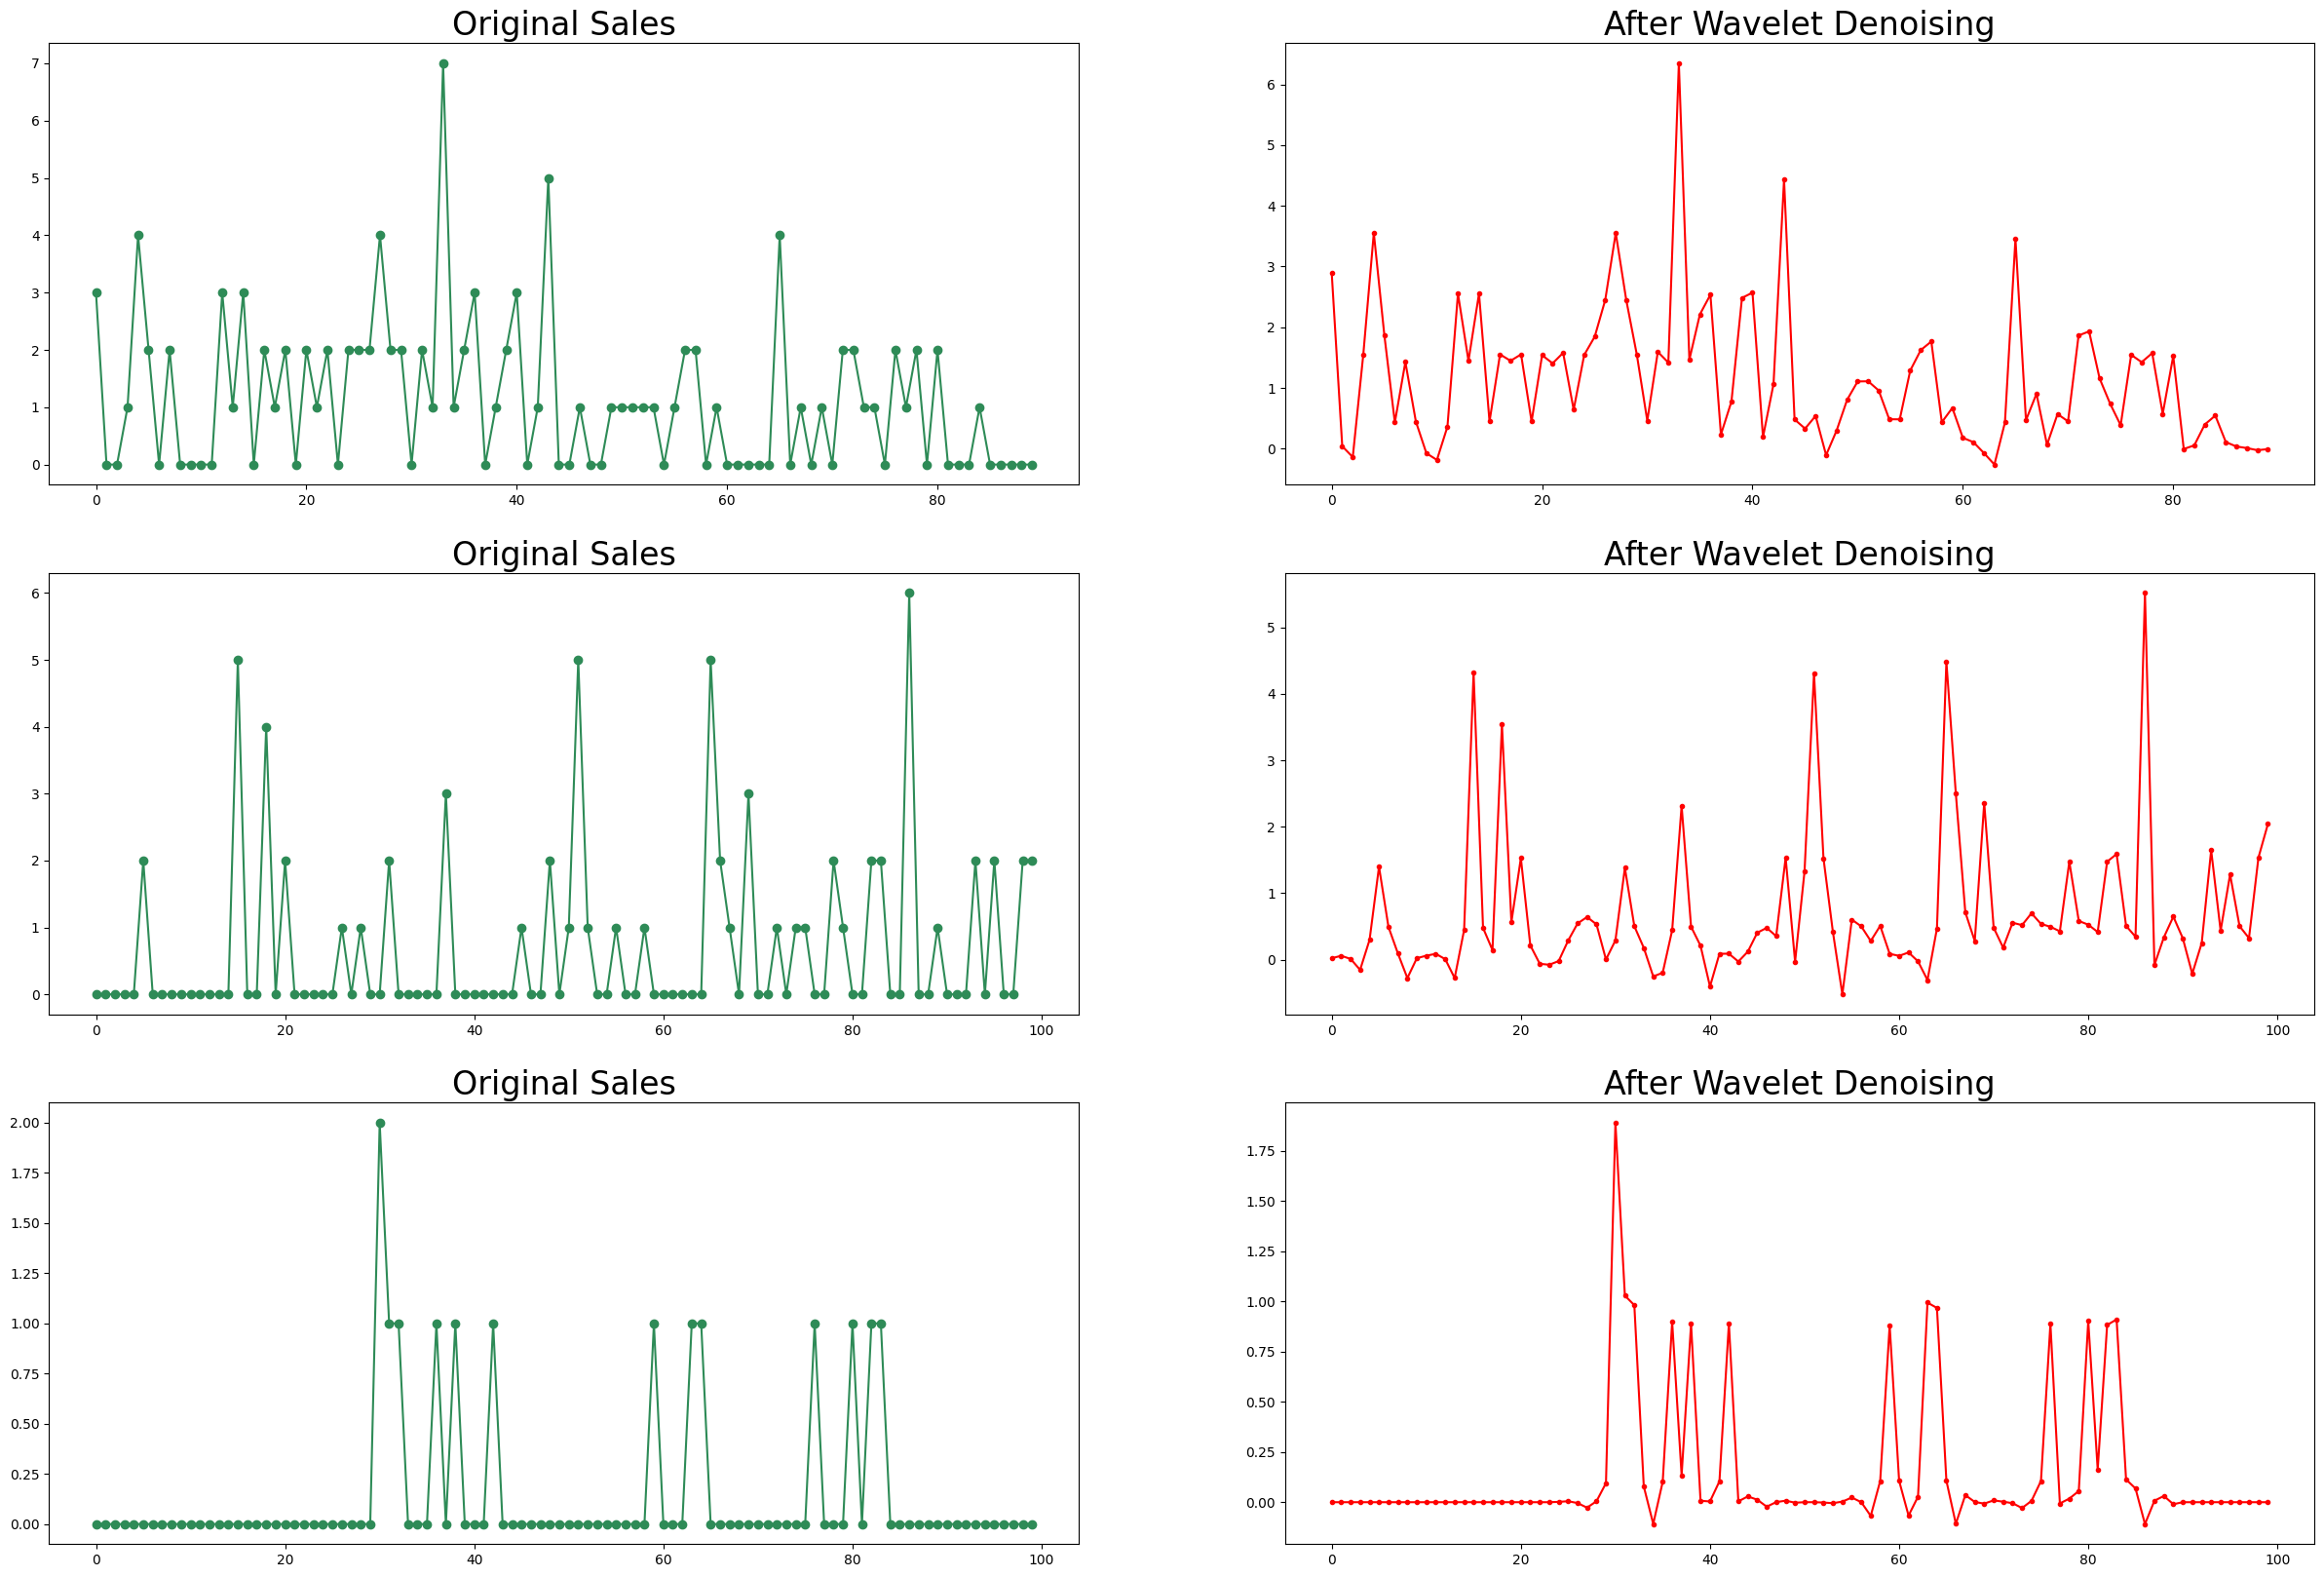

In [38]:
import pywt
def wavelet_denoise(signal, wavelet='db4', level=1):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    coeffs[1:] = [pywt.threshold(c, np.std(c)/2, mode="soft") for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

# Apply denoising
y_w1 = wavelet_denoise(x_1)
y_w2 = wavelet_denoise(x_2)
y_w3 = wavelet_denoise(x_3)
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(30, 20))

ax[0, 0].plot(x_1, color='seagreen', marker='o') 
ax[0, 0].set_title('Original Sales', fontsize=24)
ax[0, 1].plot(y_w1, color='red', marker='.') 
ax[0, 1].set_title('After Wavelet Denoising', fontsize=24)

ax[1, 0].plot(x_2, color='seagreen', marker='o') 
ax[1, 0].set_title('Original Sales', fontsize=24)
ax[1, 1].plot(y_w2, color='red', marker='.') 
ax[1, 1].set_title('After Wavelet Denoising', fontsize=24)

ax[2, 0].plot(x_3, color='seagreen', marker='o') 
ax[2, 0].set_title('Original Sales', fontsize=24)
ax[2, 1].plot(y_w3, color='red', marker='.') 
ax[2, 1].set_title('After Wavelet Denoising', fontsize=24)

plt.show()

In [39]:
train_dataset = sales_train_val[d_cols[-100:-30]]
val_dataset = sales_train_val[d_cols[-30:]]

In [40]:
fig = make_subplots(rows=3, cols=1)

fig.add_trace(
    go.Scatter(x=np.arange(70), mode='lines', y=train_dataset.loc[0].values, marker=dict(color="dodgerblue"), showlegend=False,
               name="Original signal"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=val_dataset.loc[0].values, mode='lines', marker=dict(color="darkorange"), showlegend=False,
               name="Denoised signal"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70), mode='lines', y=train_dataset.loc[1].values, marker=dict(color="dodgerblue"), showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=val_dataset.loc[1].values, mode='lines', marker=dict(color="darkorange"), showlegend=False),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70), mode='lines', y=train_dataset.loc[2].values, marker=dict(color="dodgerblue"), showlegend=False),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=val_dataset.loc[2].values, mode='lines', marker=dict(color="darkorange"), showlegend=False),
    row=3, col=1
)

fig.update_layout(height=1200, width=800, title_text="Train (blue) vs. Validation (orange) sales")
fig.show()


In [41]:
dates = ["2007-12-" + str(i) for i in range(1, 31)]
predictions = []
for row in tqdm(train_dataset[train_dataset.columns[-30:]].values[:3]):
    df = pd.DataFrame(np.transpose([dates, row]))
    df.columns = ["ds", "y"]
    model = Prophet(daily_seasonality=True)
    model.fit(df)
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)["yhat"].loc[30:].values
    predictions.append(forecast)
predictions = np.array(predictions).reshape((-1, 30))
error_prophet = np.linalg.norm(predictions[:3] - val_dataset.values[:3])/len(predictions[0])

  0%|          | 0/3 [00:00<?, ?it/s]

01:25:09 - cmdstanpy - INFO - Chain [1] start processing
01:25:10 - cmdstanpy - INFO - Chain [1] done processing
01:25:10 - cmdstanpy - INFO - Chain [1] start processing
01:25:10 - cmdstanpy - INFO - Chain [1] done processing
01:25:10 - cmdstanpy - INFO - Chain [1] start processing
01:25:10 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
pred_1 = predictions[0]
pred_2 = predictions[1]
pred_3 = predictions[2]

fig = make_subplots(rows=3, cols=1)

fig.add_trace(
    go.Scatter(x=np.arange(70), mode='lines', y=train_dataset.loc[0].values, marker=dict(color="dodgerblue"),
               name="Train"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=val_dataset.loc[0].values, mode='lines', marker=dict(color="darkorange"),
               name="Val"),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=pred_1, mode='lines', marker=dict(color="seagreen"),
               name="Pred"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70), mode='lines', y=train_dataset.loc[1].values, marker=dict(color="dodgerblue"), showlegend=False),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=val_dataset.loc[1].values, mode='lines', marker=dict(color="darkorange"), showlegend=False),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=pred_2, mode='lines', marker=dict(color="seagreen"), showlegend=False,
               name="Denoised signal"),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=np.arange(70), mode='lines', y=train_dataset.loc[2].values, marker=dict(color="dodgerblue"), showlegend=False),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=val_dataset.loc[2].values, mode='lines', marker=dict(color="darkorange"), showlegend=False),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(x=np.arange(70, 100), y=pred_3, mode='lines', marker=dict(color="seagreen"), showlegend=False,
               name="Denoised signal"),
    row=3, col=1
)

fig.update_layout(height=1200, width=800, title_text="Prophet")
fig.show()


Prophet appears to output very similar-shaped predictions to ARIMA. But on closer observation, we can see that the there is a macroscopic upward trend which was absent in ARIMA. In the ARIMA predictions, the exact same pattern was repeated. But in the Prophet predictions, the same pattern is shifted vertically at each oscillation. This shows that is able to capture high-level trends better than ARIMA.



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load datasets
calendar_df = pd.read_csv("calendar.csv")
sales_df = pd.read_csv("sales_train_validation.csv")
sell_prices_df = pd.read_csv("sell_prices.csv")

# Convert sales data to time-series format
# Selecting a single product for demonstration (can be extended to multiple categories)
example_product = sales_df.iloc[0, 6:]  # Ignore first 6 columns (meta-data)
example_product = example_product.T.reset_index()
example_product.columns = ['ds', 'y']  # Prophet requires 'ds' for date and 'y' for target variable

########################################################
# Rename the original 'ds' to 'ds_old' BEFORE merging.
########################################################
example_product.rename(columns={'ds': 'ds_old'}, inplace=True)

# Merge with calendar to get actual dates and event features
calendar_df = calendar_df[['d', 'date', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'weekday', 'wday', 'month', 'year']]
example_product = example_product.merge(calendar_df, left_on='ds_old', right_on='d', how='left')

# Drop the old columns
example_product.drop(columns=['d'], inplace=True, errors='ignore')

# Now rename 'date' --> 'ds'
example_product.rename(columns={'date': 'ds'}, inplace=True)

# Remove any duplicate columns
example_product = example_product.loc[:, ~example_product.columns.duplicated()]

# Ensure ds is unique
example_product = example_product.drop_duplicates(subset=['ds'], keep='first')

# Convert date to datetime format
example_product['ds'] = pd.to_datetime(example_product['ds'], errors='coerce')
example_product.dropna(subset=['ds'], inplace=True)
example_product.head()


,ds_old,y,ds,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,weekday,wday,month,year
0,d_1,0,2011-01-29,NaN,NaN,NaN,NaN,0,0,0,Saturday,1,1,2011
1,d_2,0,2011-01-30,NaN,NaN,NaN,NaN,0,0,0,Sunday,2,1,2011
2,d_3,0,2011-01-31,NaN,NaN,NaN,NaN,0,0,0,Monday,3,1,2011
3,d_4,0,2011-02-01,NaN,NaN,NaN,NaN,1,1,0,Tuesday,4,2,2011
4,d_5,0,2011-02-02,NaN,NaN,NaN,NaN,1,0,1,Wednesday,5,2,2011


In [49]:
# Feature Engineering: Create event and SNAP indicators
example_product['event_flag'] = example_product[['event_name_1', 'event_name_2']].notnull().any(axis=1).astype(int)
example_product['snap_usage'] = example_product[['snap_CA', 'snap_TX', 'snap_WI']].sum(axis=1)  # Aggregate SNAP usage across states
example_product['is_weekend'] = example_product['wday'].apply(lambda x: 1 if x in [1, 2] else 0)  # Flag weekends (Saturday = 1, Sunday = 2)
example_product['month'] = example_product['ds'].dt.month  # Extract month for seasonality
example_product['year'] = example_product['ds'].dt.year  # Extract year for long-term trends
example_product['lag_7'] = example_product['y'].shift(7)  # One-week lag sales feature
example_product['lag_14'] = example_product['y'].shift(14)  # Two-week lag sales feature

# Drop unneeded columns
example_product.drop(columns=['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'weekday', 'wday'], inplace=True, errors='ignore')

# Fill NaN values from lag features
example_product.fillna(0, inplace=True)
example_product.head()

/var/folders/y8/_ml2syv942nb7z2cq5jtyb500000gn/T/ipykernel_48482/757192769.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  example_product.fillna(0, inplace=True)


,ds_old,y,ds,month,year,event_flag,snap_usage,is_weekend,lag_7,lag_14
0,d_1,0,2011-01-29,1,2011,0,0,1,0,0
1,d_2,0,2011-01-30,1,2011,0,0,1,0,0
2,d_3,0,2011-01-31,1,2011,0,0,0,0,0
3,d_4,0,2011-02-01,2,2011,0,2,0,0,0
4,d_5,0,2011-02-02,2,2011,0,2,0,0,0


In [41]:
# Prophet Model Setup
model = Prophet()
model.add_regressor('event_flag')  # Adding event flag as a regressor
model.add_regressor('snap_usage')  # Adding SNAP usage as a regressor
model.add_regressor('is_weekend')  # Adding weekend flag as a regressor
model.add_regressor('month')       # Adding month for seasonality
model.add_regressor('year')        # Adding year for long-term trends
model.add_regressor('lag_7')       # Adding lag feature
model.add_regressor('lag_14')      # Adding second lag feature

# Fit the model
model.fit(example_product[['ds', 'y', 'event_flag', 'snap_usage', 'is_weekend', 'month', 'year', 'lag_7', 'lag_14']])

# Make future predictions
future = model.make_future_dataframe(periods=383)  # Forecasting 90 days ahead
future['event_flag'] = 0  # Assume no events in future (modify as needed)
future['snap_usage'] = 0  # Assume no future SNAP variations
future['is_weekend'] = future['ds'].dt.weekday.apply(lambda x: 1 if x in [5, 6] else 0)  # Recalculate weekends
future['month'] = future['ds'].dt.month
future['year'] = future['ds'].dt.year
future['lag_7'] = 0  # Placeholder for future lag
future['lag_14'] = 0 # Placeholder for future lag

forecast = model.predict(future)

11:45:53 - cmdstanpy - INFO - Chain [1] start processing
11:45:53 - cmdstanpy - INFO - Chain [1] done processing


Model Performance:
MAE: 0.39
MSE: 0.37
RMSE: 0.61


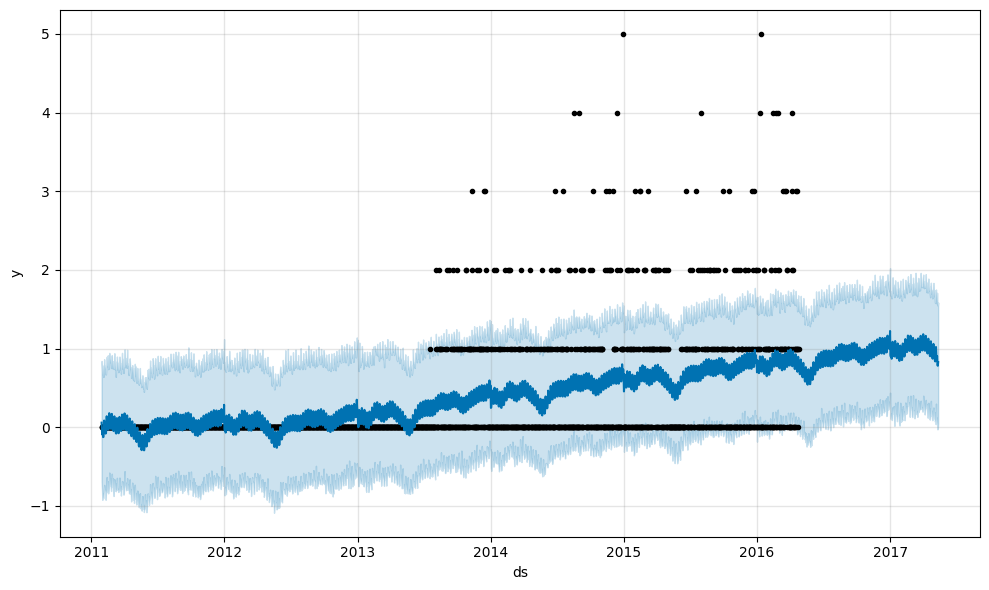

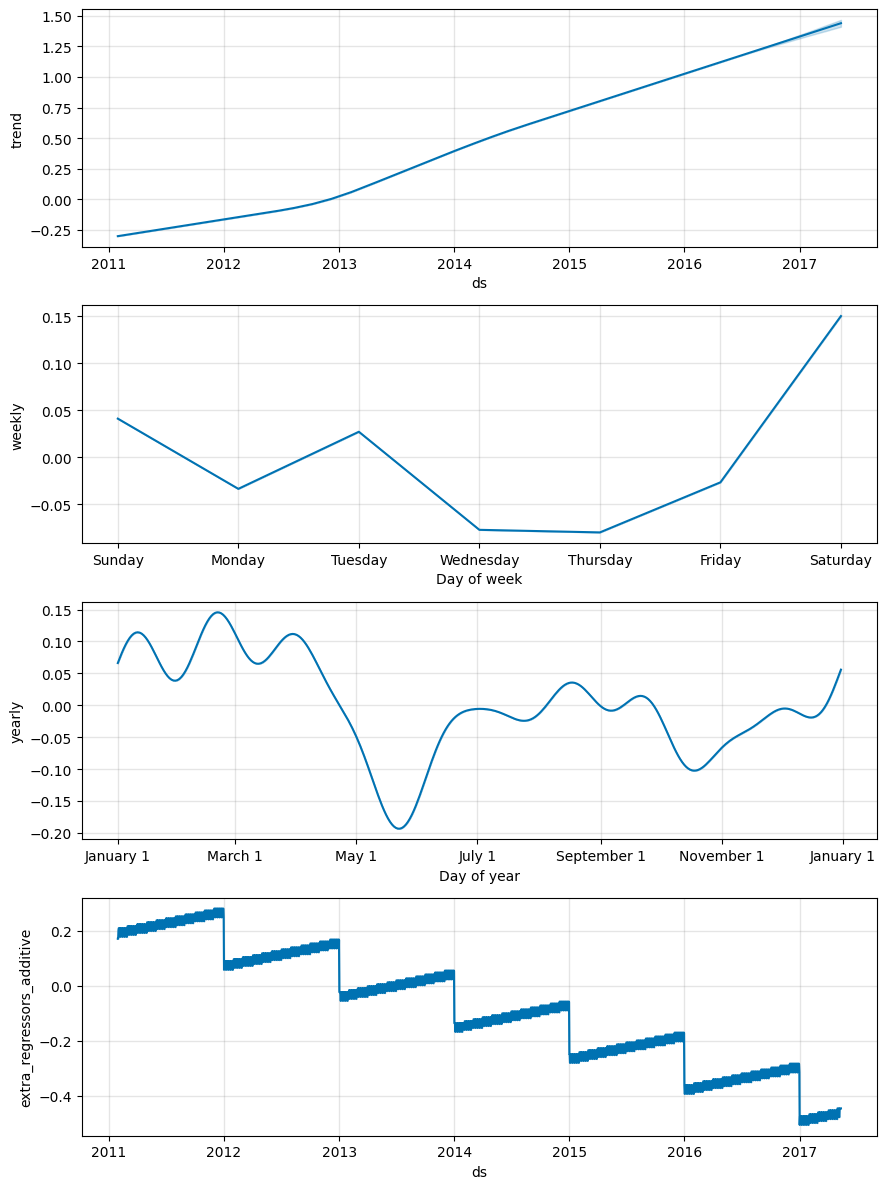

In [42]:
# Evaluate Model Performance (on historical data)
predictions = model.predict(example_product[['ds', 'event_flag', 'snap_usage', 'is_weekend', 'month', 'year', 'lag_7', 'lag_14']])
y_true = example_product['y']
y_pred = predictions['yhat']
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print(f"Model Performance:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nRMSE: {rmse:.2f}")

# Plot the forecast
fig = model.plot(forecast)
plt.show()

# Plot components
fig2 = model.plot_components(forecast)
plt.show()


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

def forecast_for_store(store_id, sales_df, calendar_df):
    
    # ------------------------------------------------------------
    # STEP A: Filter sales data by store_id
    # ------------------------------------------------------------
    store_mask = (sales_df['store_id'] == store_id)
    store_sales = sales_df[store_mask]
    
    d_cols = [c for c in store_sales.columns if 'd_' in c]
    daily_sales = store_sales[d_cols].sum(axis=0)
    
    store_df = daily_sales.reset_index()
    store_df.columns = ['ds', 'y']
    
    # ------------------------------------------------------------
    # STEP B: Merge with calendar to get actual date + features
    # ------------------------------------------------------------
    store_df.rename(columns={'ds': 'ds_old'}, inplace=True)
    
    cal_cols = [
        'd', 'date', 'event_name_1', 'event_type_1', 'event_name_2',
        'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI',
        'weekday', 'wday', 'month', 'year'
    ]
    calendar_subset = calendar_df[cal_cols].copy()
    
    store_df = store_df.merge(calendar_subset, left_on='ds_old', right_on='d', how='left')
    store_df.drop(columns=['d'], inplace=True, errors='ignore')
    store_df.rename(columns={'date': 'ds'}, inplace=True)
    
    store_df['ds'] = pd.to_datetime(store_df['ds'], errors='coerce')
    store_df.dropna(subset=['ds'], inplace=True)
    
    # ------------------------------------------------------------
    # STEP C: Train-Test Split
    # ------------------------------------------------------------
    split_date = store_df['ds'].max() - pd.DateOffset(days=383)
    train_df = store_df[store_df['ds'] <= split_date]
    test_df = store_df[store_df['ds'] > split_date]
    
    # ------------------------------------------------------------
    # STEP D: Train Prophet Model
    # ------------------------------------------------------------
    model = Prophet(seasonality_mode='multiplicative')
    
    model.fit(train_df[['ds', 'y']])
    
    # ------------------------------------------------------------
    # STEP E: Forecast
    # ------------------------------------------------------------
    future = model.make_future_dataframe(periods=383)
    forecast = model.predict(future)
    
    #RMSE
    forecast_test = forecast[['ds', 'yhat']].merge(test_df[['ds', 'y']], on='ds', how='left').dropna()
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    
    print(f"RMSE for Store {store_id}: {rmse:.2f}")

    # ------------------------------------------------------------
    # STEP F: Visualization
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 6))

    # Training data in black
    plt.plot(train_df['ds'], train_df['y'], 'k-', label='Training Data')

    # Test data in blue
    plt.plot(test_df['ds'], test_df['y'], 'b-', label='Test Data')

    # Forecast in red
    plt.plot(forecast['ds'], forecast['yhat'], 'r-', label='Forecast')

    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.title(f"Sales Forecast for Store {store_id}")
    plt.legend()
    plt.show()
    
    return model, forecast, rmse

# Example usage:
# model, forecast = forecast_for_store("CA_1", sales_df, calendar_df)


11:51:10 - cmdstanpy - INFO - Chain [1] start processing
11:51:10 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store CA_1: 467.18


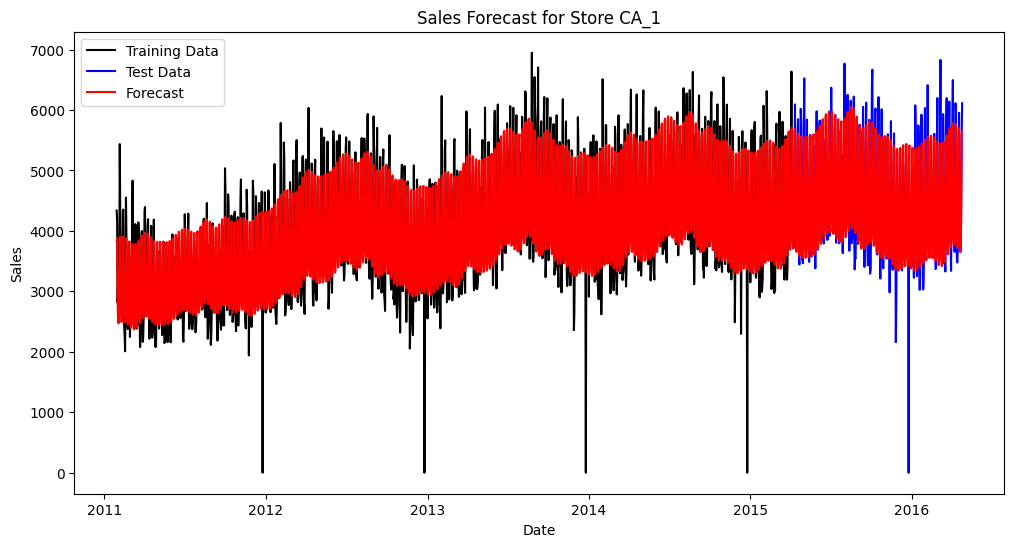

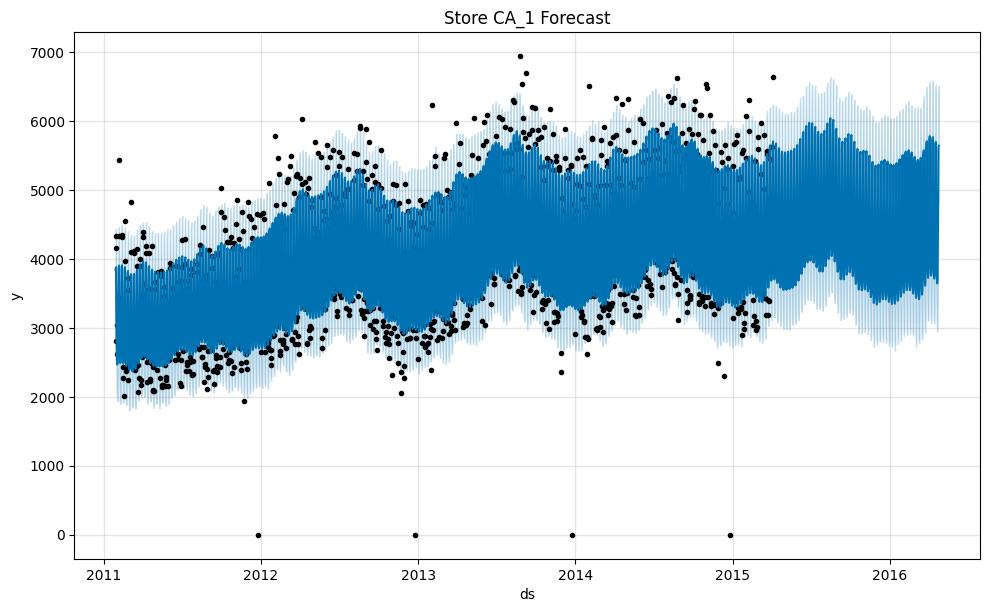

11:51:10 - cmdstanpy - INFO - Chain [1] start processing
11:51:11 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store CA_2: 1998.94


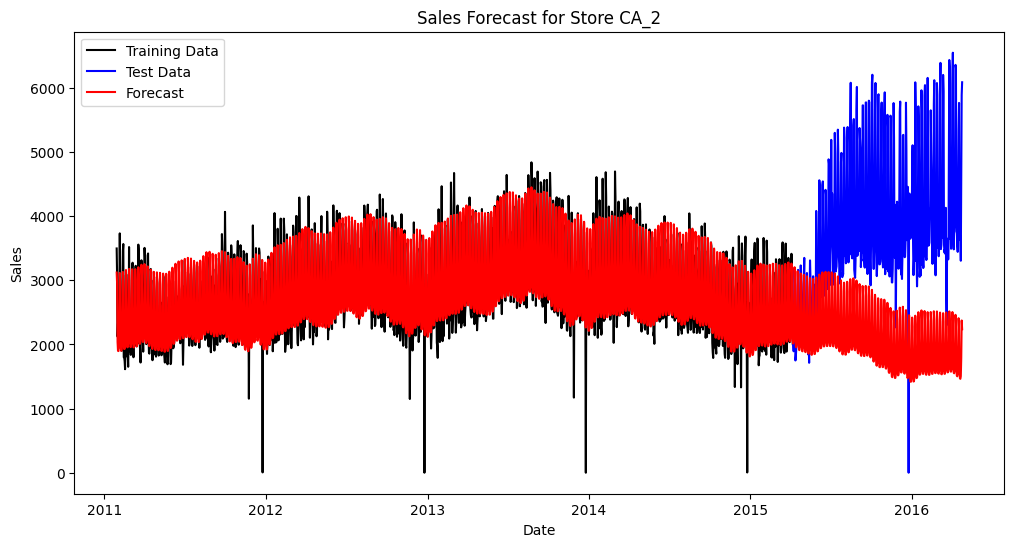

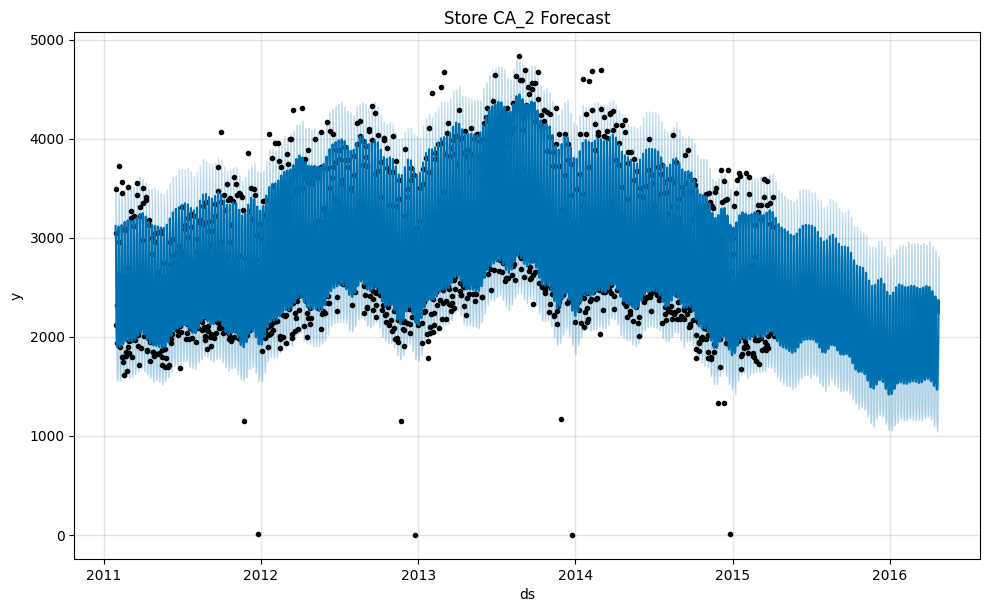

11:51:11 - cmdstanpy - INFO - Chain [1] start processing
11:51:11 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store CA_3: 588.12


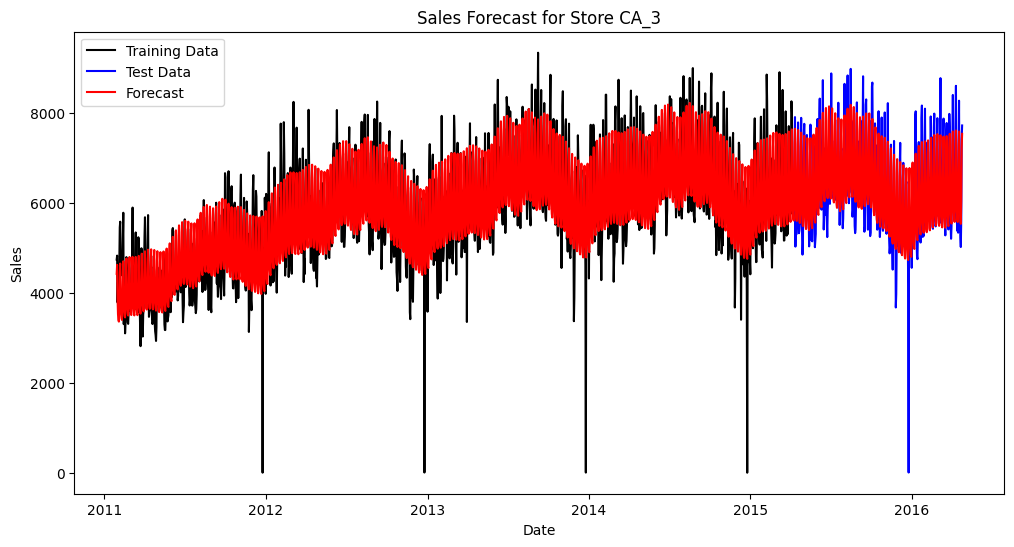

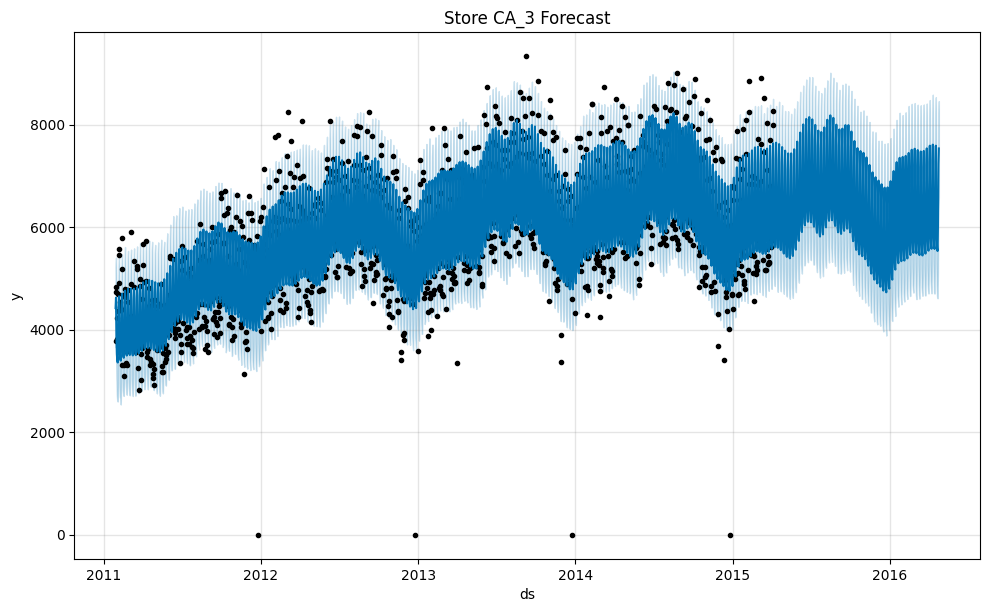

11:51:11 - cmdstanpy - INFO - Chain [1] start processing
11:51:11 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store CA_4: 263.96


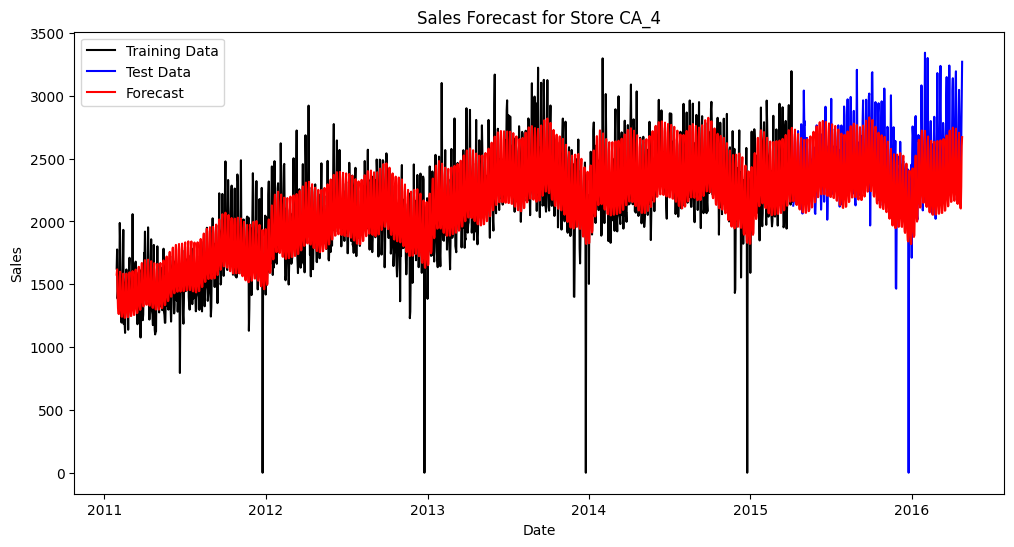

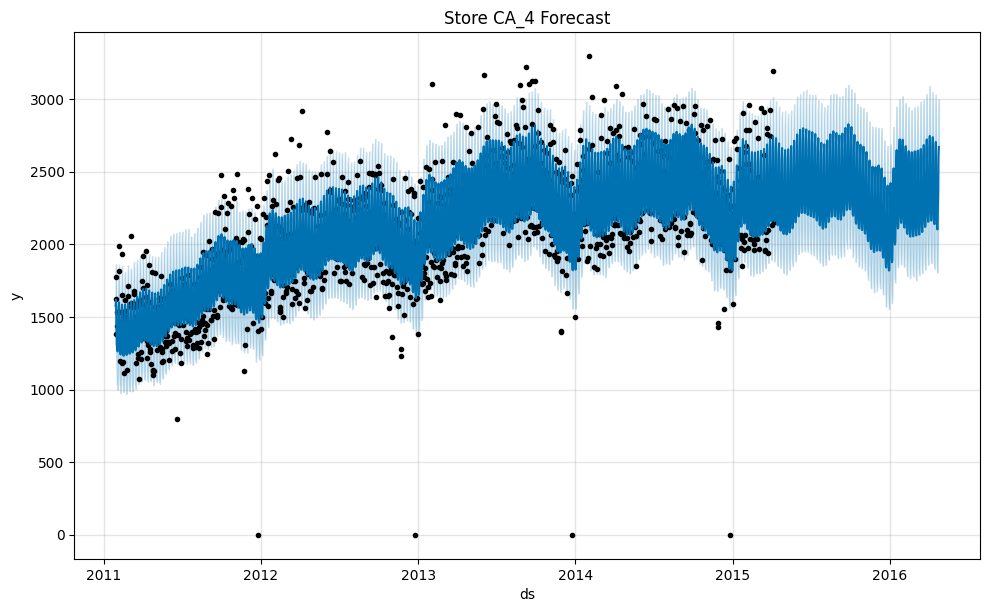

11:51:12 - cmdstanpy - INFO - Chain [1] start processing
11:51:12 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store TX_1: 342.00


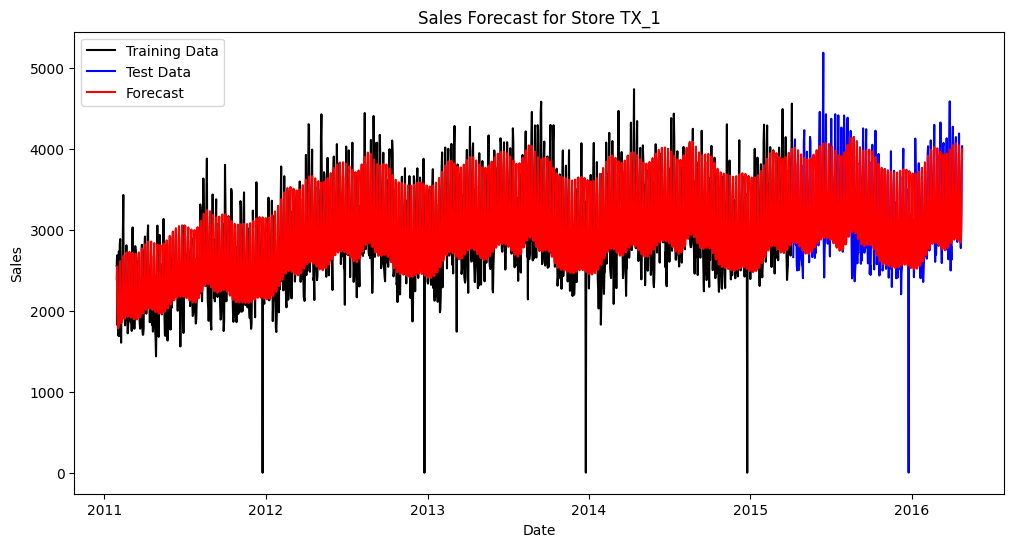

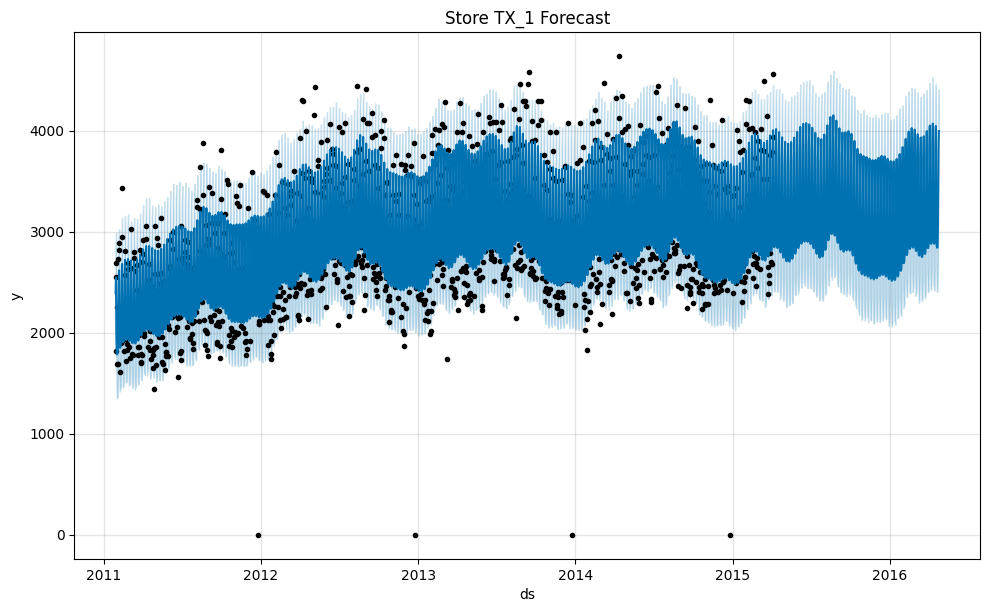

11:51:13 - cmdstanpy - INFO - Chain [1] start processing
11:51:13 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store TX_2: 520.30


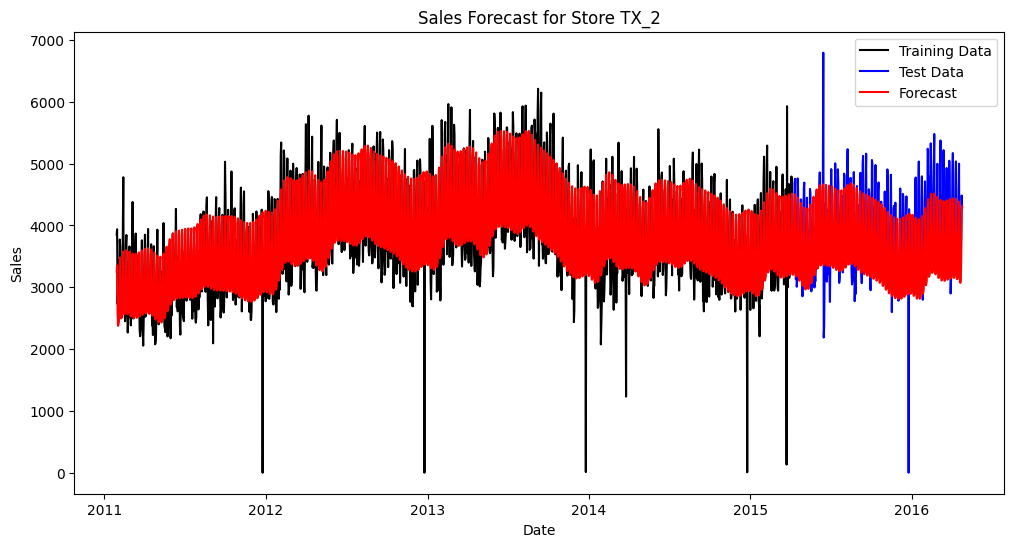

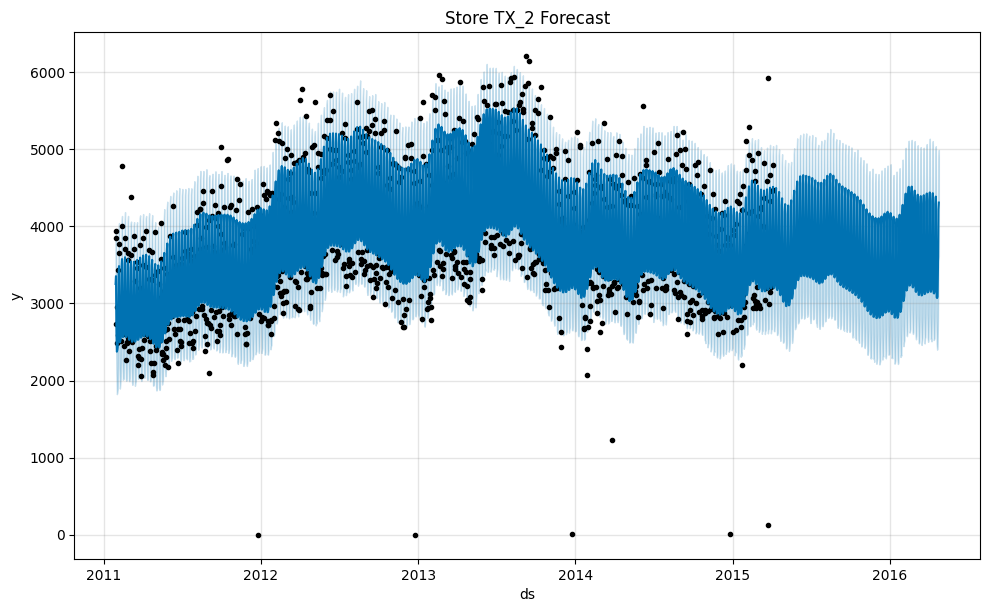

11:51:13 - cmdstanpy - INFO - Chain [1] start processing
11:51:13 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store TX_3: 454.90


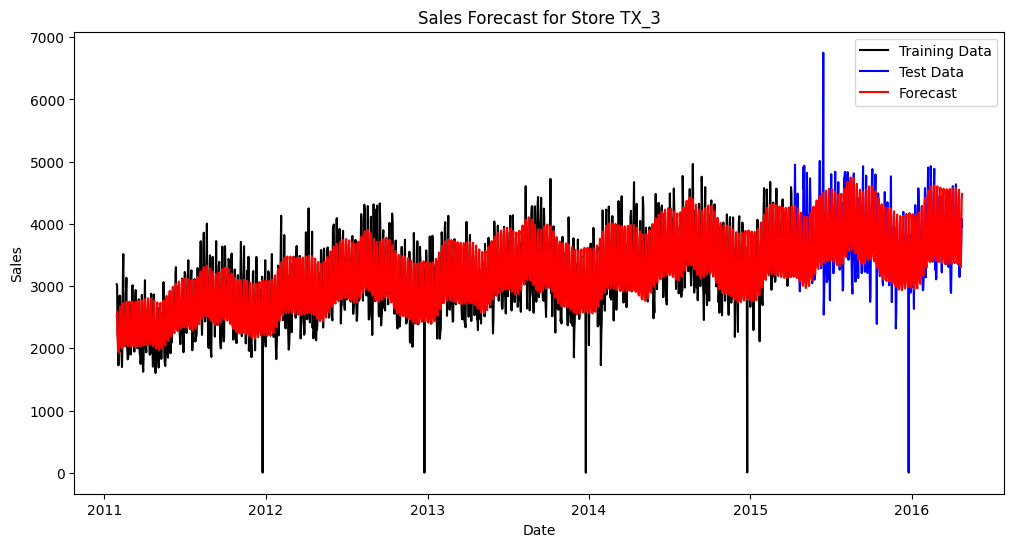

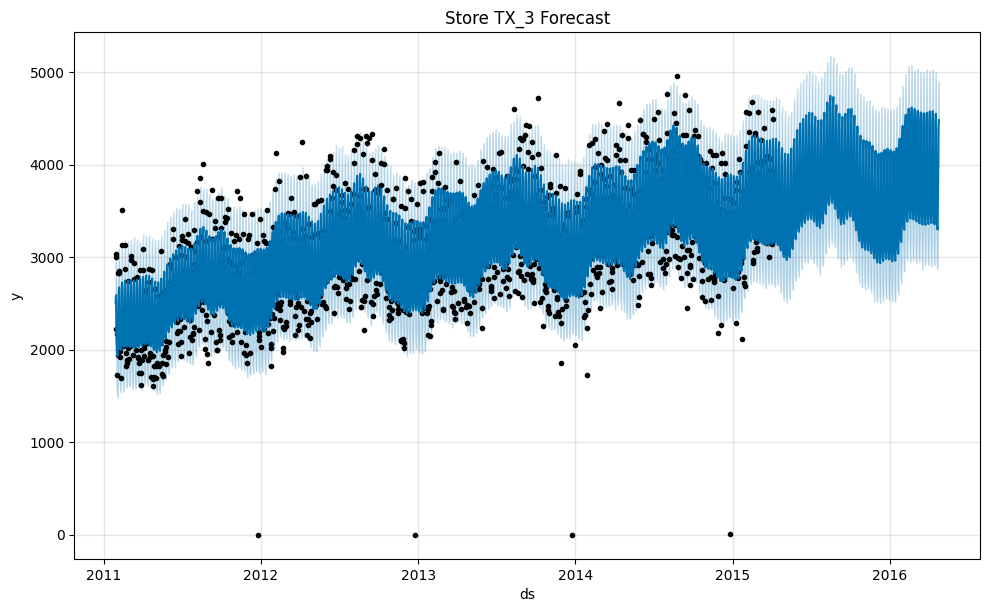

11:51:14 - cmdstanpy - INFO - Chain [1] start processing
11:51:14 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store WI_1: 492.70


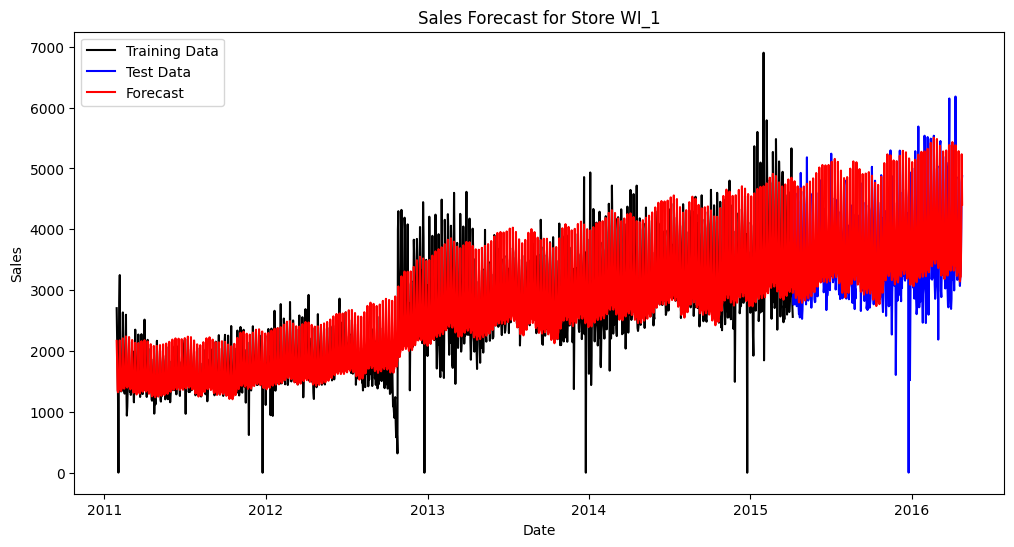

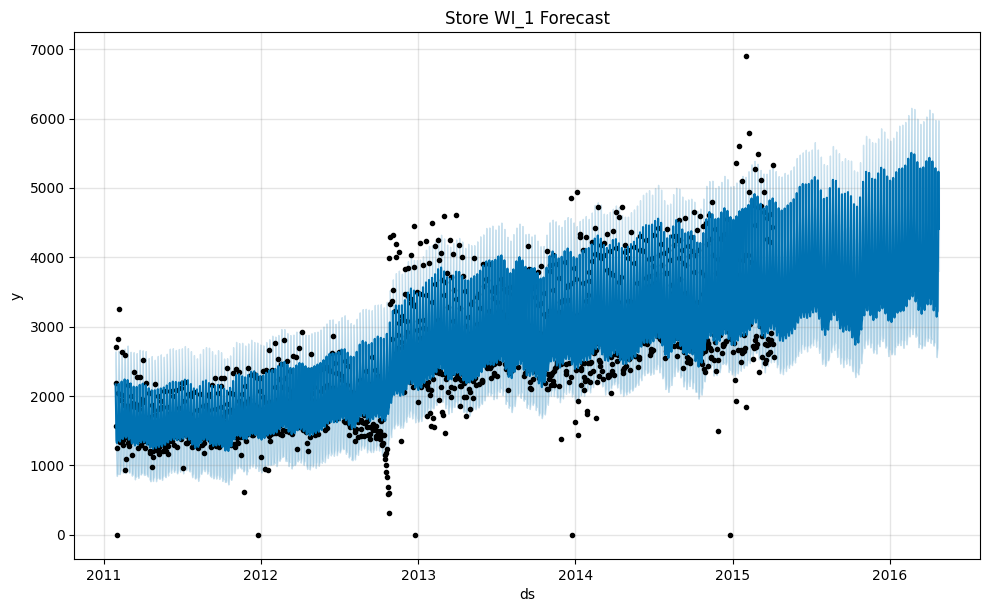

11:51:14 - cmdstanpy - INFO - Chain [1] start processing
11:51:14 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store WI_2: 1028.32


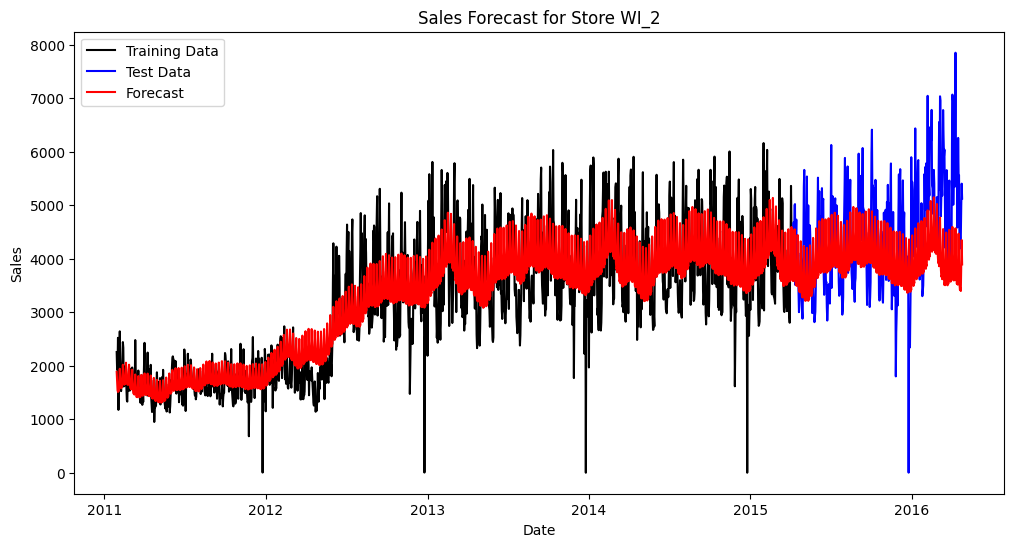

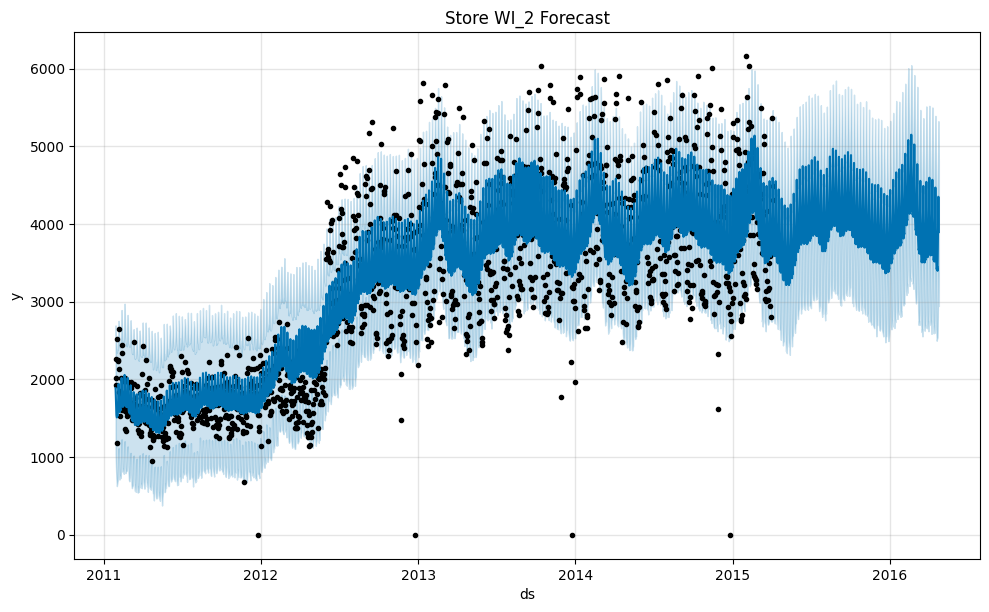

11:51:15 - cmdstanpy - INFO - Chain [1] start processing
11:51:15 - cmdstanpy - INFO - Chain [1] done processing


RMSE for Store WI_3: 922.01


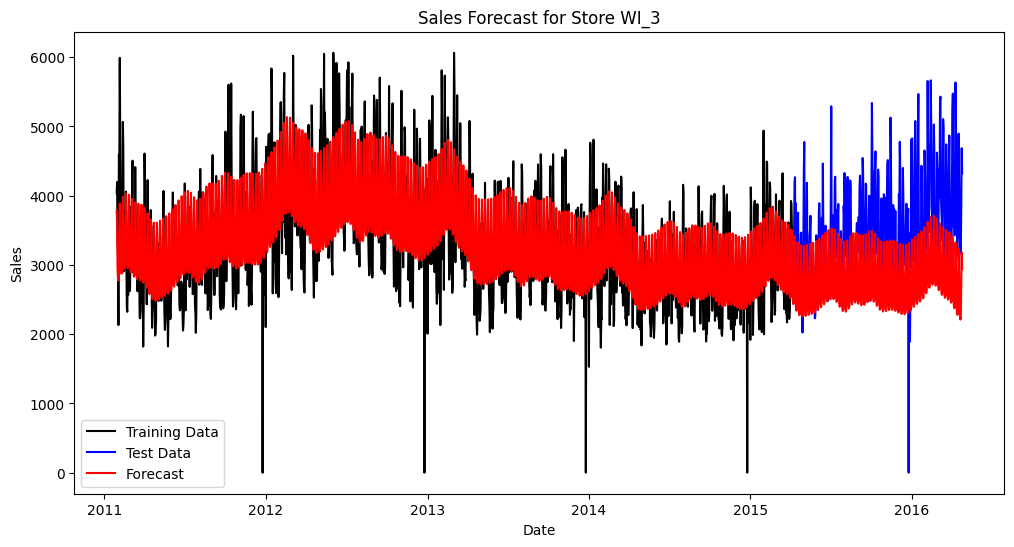

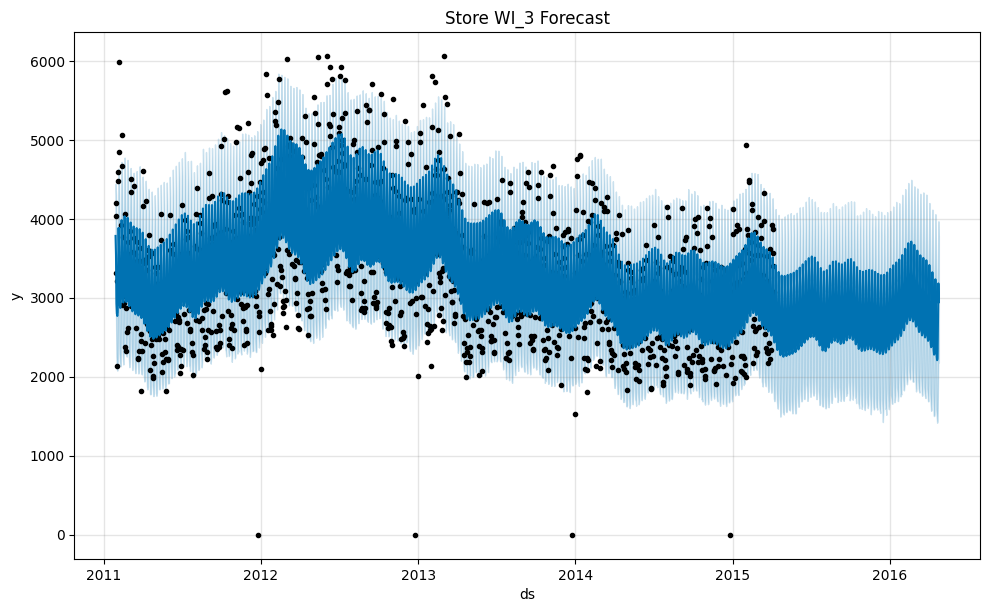


RMSE Values for All Stores:
Store CA_1: RMSE = 467.18
Store CA_2: RMSE = 1998.94
Store CA_3: RMSE = 588.12
Store CA_4: RMSE = 263.96
Store TX_1: RMSE = 342.00
Store TX_2: RMSE = 520.30
Store TX_3: RMSE = 454.90
Store WI_1: RMSE = 492.70
Store WI_2: RMSE = 1028.32
Store WI_3: RMSE = 922.01


In [47]:
from sklearn.metrics import mean_squared_error

# Run forecasts for all stores
rmse_results = {}
unique_stores = sales_train_val['store_id'].unique()

for s_id in unique_stores:
    model, fcst, rmse = forecast_for_store(s_id, sales_train_val, calendar)
    rmse_results[s_id] = rmse 
    # Plot forecast
    fig = model.plot(fcst)
    plt.title(f"Store {s_id} Forecast")
    plt.show()

print("\nRMSE Values for All Stores:")
for store, rmse_value in rmse_results.items():
    print(f"Store {store}: RMSE = {rmse_value:.2f}")
